## Analysis
Primary questions to answer:
1. How many permits/approvals does SHPD do within a month? A day?
2. Calculate the corresponding rate per week/month that they take to give a decision
3. If there are two statues invoked (very rare based on other analysis), what is the delay between the two of them?
4. If we take the year involved with the construction of the project number, can we at the very minimum see the permits that are resolved within the year, more than one year, and more than two years?
5. How can we break this down by the groups I made and categorized?
6. Is there a way to visualize the tax map keys to pinpoint certain areas that deserve more/less attention?

In [1]:
import pandas as pd
import numpy as np
import statsmodels as sm
import seaborn as sns
import matplotlib.pyplot as plt
from great_tables import GT
from plotnine import *

In [2]:
path = '../clean-data/shpd-labelled.csv'
df = pd.read_csv(path)
df.drop_duplicates()

df['Date Opinion 6E'] = pd.to_datetime(df['Date Opinion 6E'], utc=True)
df['Date Opinion 106'] = pd.to_datetime(df['Date Opinion 106'], utc=True)

print(df['Date Opinion 6E'].dtype) # datetime64[ns, UTC]
valid_years = range(2021,2025,1)
df = df[df['Date Opinion 6E'].dt.year.isin(valid_years)]
print(df.columns)

df['Daily Count 6E'] = df.groupby(df['Date Opinion 6E'].dt.date)['Project Number'].transform('count')
df['Daily Count 106'] = df.groupby(df['Date Opinion 106'].dt.date)['Project Number'].transform('count')

# remove the weird opinion dates that actually don't fall under 2021-2024

rc_data = pd.read_excel("../raw-data/SHPD consolidated.xlsx", sheet_name="20-24 RC name fix")
print(rc_data.columns)
# convert into string to clean initially
rc_data["Date Created"] = rc_data["Date Created"].astype(str)
# getting everything to the year 20--
rc_data["Date Created"] = rc_data["Date Created"].str.replace(r'(\d{2})(\d{2})', r'20\2', regex=True)

# forcing everything to be a date
rc_data["Date Created"] = pd.to_datetime(rc_data["Date Created"], utc=True, errors = "coerce")
# making anything under 2010 be NA because it is likely a wrong datetime
rc_data.loc[rc_data['Date Created'].dt.year < 2010, 'Date Created'] = pd.NaT
# drop all the NAs that we have
rc_data = rc_data.dropna(subset = ['Date Created'])
# remove unnecessary cols
rc_data = rc_data.drop(columns=['Project Name', 'Island', 'Tax Map Keys', 'Unnamed: 9', 'Statutes', 'Agency', 5932])
print(rc_data["Date Created"].head())

df = pd.merge(df, rc_data, how = "left", on = "Project Number")
print(df['Date Created'].value_counts)

# calculating delay 
df['time_6e'] = (df['Date Opinion 6E'] - df['Date Created']).dt.days
df['time_106'] = (df['Date Opinion 106'] - df['Date Created']).dt.days

# im concerned I deleted something
df[['time_6e', 'time_106']] = df[['time_6e', 'time_106']]
print(df['time_6e'].describe())


datetime64[us, UTC]
Index(['Unnamed: 0', 'Project Name', 'Project Number', 'Date Opinion 106',
       'Opinion 106', 'Opinion 106 Comment', 'Date Opinion 6E', 'Opinion 6E',
       'Opinion 6E Comment', 'Statutes', 'Agency', 'Island', 'Tax Map Keys',
       'Label', 'opinion_6e_binary', 'cluster', 'topic', 'Category_Scored',
       'Confidence'],
      dtype='str')
Index(['Project Number',   'Project Name',   'Date Created',       'Statutes',
               'Agency',       'Ahupuaas',       'District',         'Island',
         'Tax Map Keys',     'Unnamed: 9',             5932],
      dtype='object')
0   2012-03-13 00:00:00+00:00
1   2012-03-13 00:00:00+00:00
3   2012-08-30 00:00:00+00:00
4   2012-08-30 00:00:00+00:00
6   2012-11-01 00:00:00+00:00
Name: Date Created, dtype: datetime64[us, UTC]
<bound method IndexOpsMixin.value_counts of 0                            NaT
1                            NaT
2                            NaT
3                            NaT
4                 

In [3]:
original_count = len(df)

df_clean = df[
    (df['time_6e'] >= 0) | (df['time_6e'].isna())
].copy()

df_clean = df_clean[
    (df_clean['time_106'] >= 0) | (df_clean['time_106'].isna())
].copy()

dropped_rows = original_count - len(df_clean)
print(f"Dropped {dropped_rows} rows with negative delays.")

# go back to just df for the sake of the rest of the script
df = df_clean.copy()


Dropped 17 rows with negative delays.


4


/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 3 rows containing non-finite values.


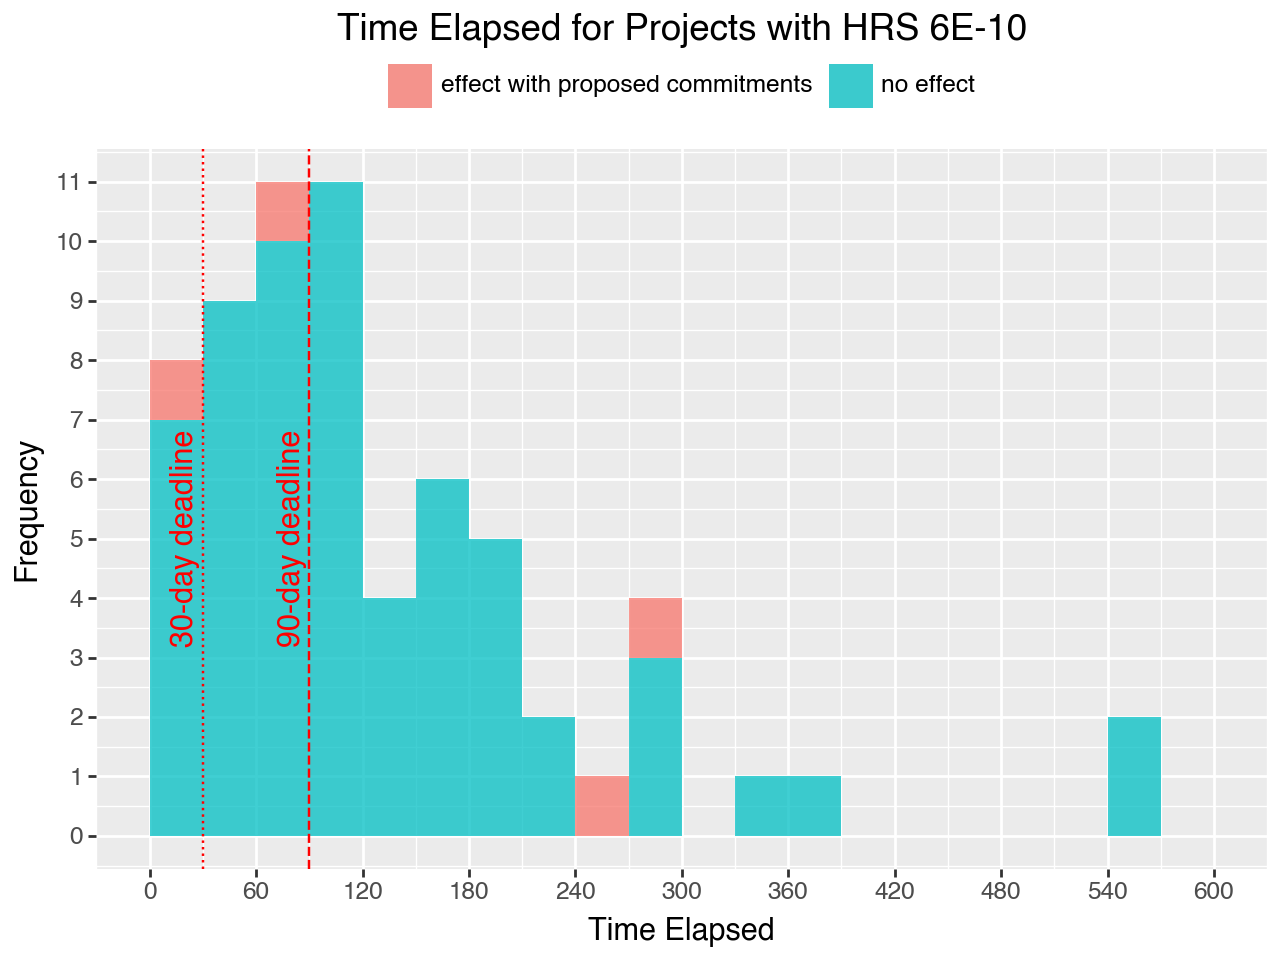

/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../images/time-6e-10.png
/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 3 rows containing non-finite values.


41


/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 174 rows containing non-finite values.


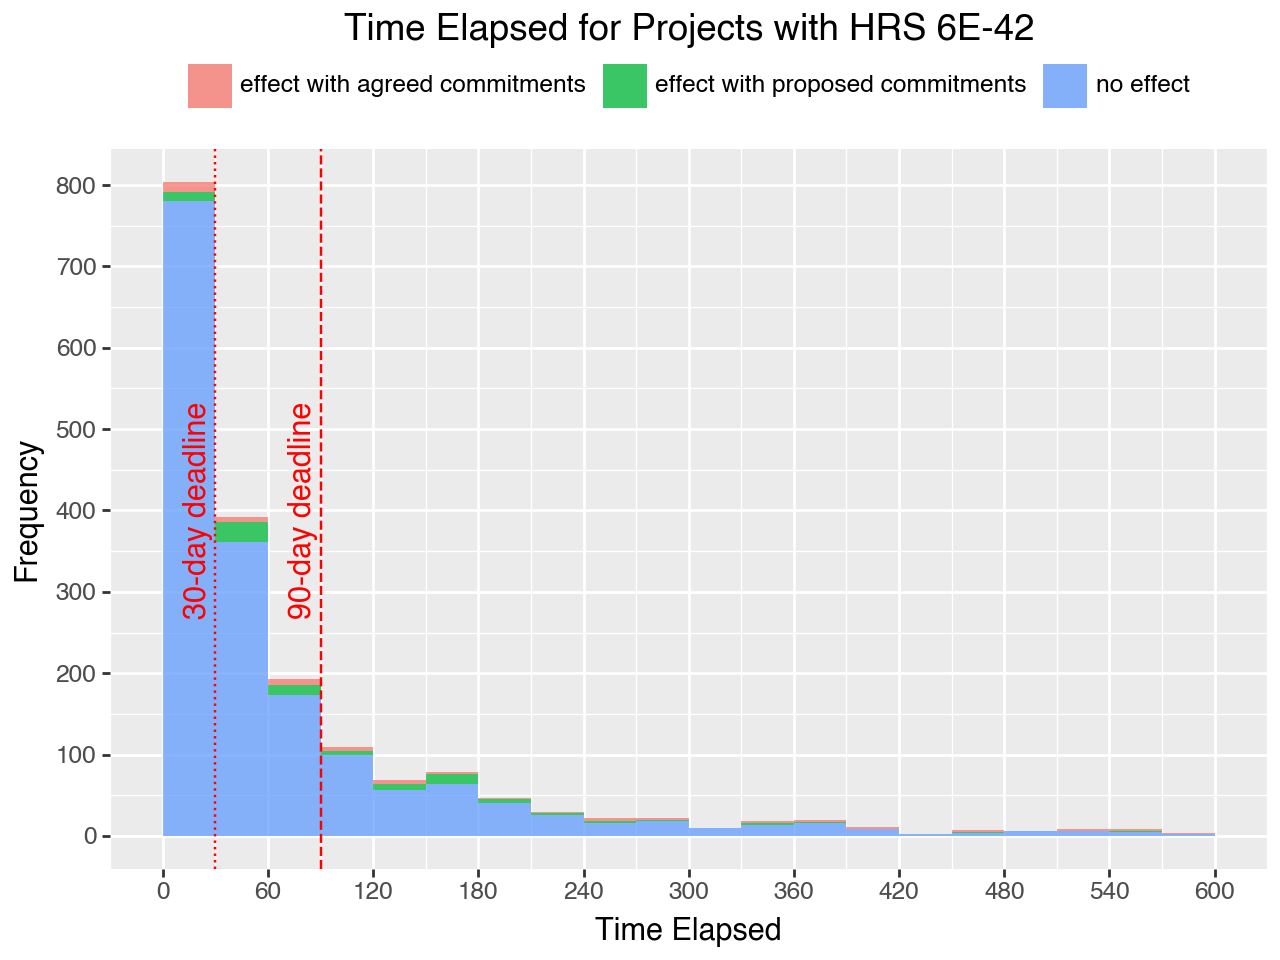

/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../images/time-6e-42.png
/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 174 rows containing non-finite values.


In [4]:
# plot of graphs that contain certain things 
from mizani.breaks import extended_breaks

'''
    here i can either do these separately, which I am inclined to do, and then config manually for labels and such
'''
def hist_plot(code, line):
    df_temp = df[df['Statutes'].str.contains(f'{code}')]
    print(np.max(df_temp['time_6e'].value_counts())) # this is of the particular day maximum

    hist = (
        ggplot(df_temp, aes(x = "time_6e", fill = "Opinion 6E")) + 
            geom_histogram(binwidth = 30, alpha = 0.75, boundary = 0) + 
            scale_x_continuous(breaks = range(0,601,60),
                               limits = (0,600)) +
            scale_y_continuous(breaks=extended_breaks(n=10)) +
            theme(legend_position = "top", legend_direction = "horizontal", legend_title = element_blank()) +
            labs(x = "Time Elapsed", y = "Frequency", title = f"Time Elapsed for Projects with HRS {code}")
    )
    # hist.show()
    return hist

test1 = hist_plot('6E-10', 30) 
test1_upd = (
    test1 + 
    geom_vline(aes(xintercept = 30), color = "red", linetype = "dotted") + 
    geom_vline(aes(xintercept = 90), color = "red", linetype = "dashed") +
    annotate("text", x=20, y= 5, label="30-day deadline", angle=90, color = "red") + 
    annotate("text", x=80, y= 5, label="90-day deadline", angle=90, color = "red")
)
test1_upd.show()
test1_upd.save("../images/time-6e-10.png", dpi = 500)

test2 = hist_plot('6E-42', 30)
test2_upd = (
    test2 +
    geom_vline(aes(xintercept = 30), color = "red", linetype = "dotted") + 
    geom_vline(aes(xintercept = 90), color = "red", linetype = "dashed") +
    annotate("text", x=20, y= 400, label="30-day deadline", angle=90, color = "red") + 
    annotate("text", x=80, y= 400, label="90-day deadline", angle=90, color = "red")
)
test2_upd.show()
test2_upd.save("../images/time-6e-42.png", dpi = 500)


/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../images/freq_statutes


Island
Oʻahu          848
Hawaiʻi        815
Maui           697
Kauaʻi         268
Molokaʻi        49
Lanaʻi           7
Moku O Loʻe      1
Kahoʻolawe       1
Name: count, dtype: int64


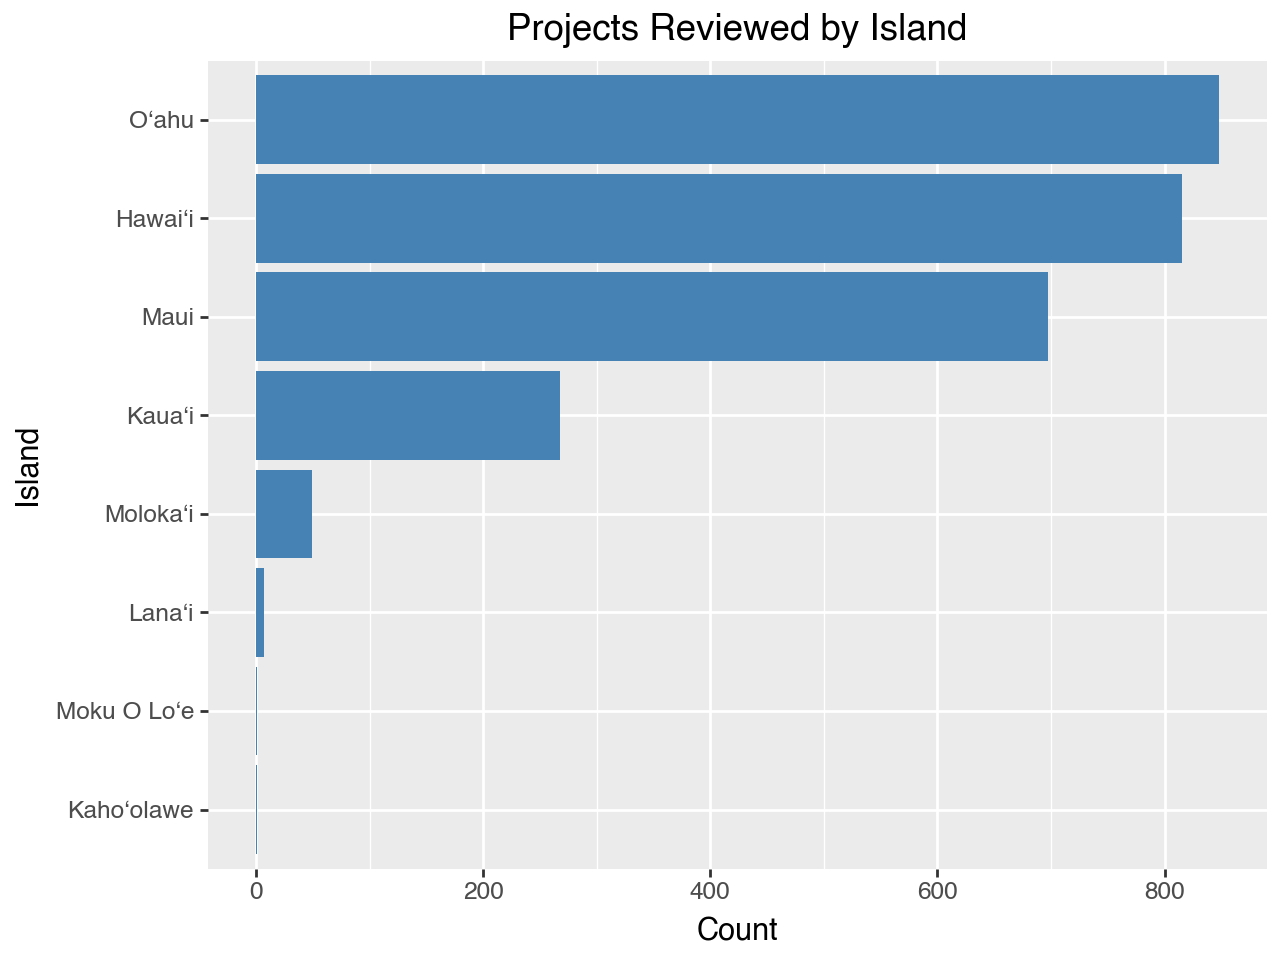

/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/kevinphan981/Programming/maui-shpd-classification/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../images/islands-freq.png


In [76]:
# the frequency in statutes being cited, I will need to break up the statutes var into separate categories.

# from mizani.transforms import pd_sort

df_clean = (
    df['Statutes']
    .str.split(',')             # Split by comma (no space)
    .dropna()
    .explode()                  # Turn list items into individual rows
    .str.strip()                # Remove leading/trailing spaces (THE FIX)
    .reset_index(name='Statute') # Turn Series back into a DataFrame
)

freq_statutes = (
    ggplot(df_clean, aes("reorder(Statute,Statute, len)"))
    + geom_bar(fill="steelblue")
    + coord_flip() # Flips the axes so statute names are readable
    + theme()
    # + scale_x_discrete(limits = pd_sort(df_clean['Statute']))
    + labs(
        title="Frequency of Statutes",
        x="Statute",
        y="Count"
    )
)
freq_statutes.show
freq_statutes.save("../images/freq_statutes", dpi = 750)

df_hawaii = (
    df['Island']
    .str.split(',')             # Split by comma (no space)
    .dropna()
    .explode()                  # Turn list items into individual rows
    .str.strip()                # Remove leading/trailing spaces (THE FIX)
    .reset_index(name='Island')
)

print(df_hawaii['Island'].value_counts())
islands = (
    ggplot(df_hawaii, aes("reorder(Island,Island, len)"))
    + geom_bar(fill="steelblue")
    + coord_flip() # Flips the axes so statute names are readable
    + theme()
    # + scale_x_discrete(limits = pd_sort(df_clean['Statute']))
    + labs(
        title="Projects Reviewed by Island",
        x="Island",
        y="Count"
    )
)
islands.show()
islands.save("../images/islands-freq.png", dpi = 750)

## Policy Adjustment
As per the policy, we allow 30 days for projects that are not adversely affected or have no effect, and 90 for those that do have an effect.

It is really only for 6e-10 and 6e-42. I will just do all of them and then subset when appropriate.

Forclosure means that the project had the worst outcomes and likely is just being closed.
    'No Historic Properies Affected'
    'No Adverse Effect'
    'Adverse Effect'
    'Foreclosure'

In [6]:
# we subtract in 30 days if the binary outcome has no effect, subtract 90 days if there is an effect of some kind.

def policy_adjust(row):
    new_delay_6e = np.nan
    new_delay_106 = np.nan
    # for 6e cases, we just do all in a blanket fashion.
    if row['Opinion 6E'] == 'no effect':
        new_delay_6e = row['time_6e'] - 30
    else: 
        new_delay_6e = row['time_6e'] - 90
    # for 106 cases,
    if row['Opinion 106'] == 'No Historic Properies Affected' or 'No Adverse Effect':
        new_delay_106 = row['time_106'] - 30
    else: 
        new_delay_106 = row['time_106'] - 90

    # new logic for the new delay value
    if new_delay_6e < 0:
        new_delay_6e = 0
    if new_delay_106 < 0:
        new_delay_106 = 0
    
    return pd.Series([new_delay_6e, new_delay_106])


# def delay_logic(row):

#     row['delay_6e'] = row['delay_6e'].astype('int')
#     row['delay_106'] = row['delay_106'].astype('int')
#     if row['delay_6e'] < 0:
#         row['delay_6e'] = 0 # force it to zero because there is no delay
#     if row['delay_106'] < 0:
#         row['delay_106'] = 0 
#     return pd.Series(['delay_6e', 'delay_106'])

df[['delay_6e', 'delay_106']] = df.apply(policy_adjust, axis = 1)
# df[['delay_6e', 'delay_106']] = df.apply(delay_logic, axis = 1)

In [7]:
df[['delay_6e', 'delay_106']].value_counts()

delay_6e  delay_106
0.0       0.0          18
26.0      26.0          3
173.0     173.0         3
83.0      83.0          2
18.0      18.0          2
                       ..
80.0      80.0          1
46.0      46.0          1
0.0       102.0         1
6.0       6.0           1
1.0       0.0           1
Name: count, Length: 112, dtype: int64

In [8]:
df.describe()

,Unnamed: 0,cluster,topic,Confidence,Daily Count 6E,Daily Count 106,time_6e,time_106,delay_6e,delay_106
count,2786.000000,2786.000000,2786.000000,1875.000000,2786.000000,172.000000,2551.000000,140.000000,2551.000000,140.000000
mean,1492.512563,3.521177,4.457645,0.649426,4.324480,1.313953,98.692278,206.278571,71.142689,177.871429
std,862.352497,2.106607,2.824966,0.185946,2.679175,0.567371,150.783280,234.075068,143.579372,232.804480
min,0.000000,0.000000,0.000000,0.214754,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,752.250000,3.000000,2.000000,0.496033,2.000000,1.000000,18.000000,45.750000,0.000000,15.750000
50%,1493.500000,3.000000,4.000000,0.671719,4.000000,1.000000,45.000000,104.000000,11.000000,74.000000
75%,2241.750000,3.000000,7.000000,0.818513,6.000000,2.000000,113.000000,286.000000,76.000000,256.000000
max,2996.000000,9.000000,9.000000,0.933090,17.000000,3.000000,1326.000000,1157.000000,1271.000000,1127.000000


In [9]:
yearly_stats = df.groupby(df['Date Opinion 6E'].dt.year)['Project Name'].count()
print(yearly_stats) # most is supposed to be from 2021 to 2024... and it does work out this way.

monthly_stats = df[df['Date Opinion 6E'].dt.year == 2023].groupby(df['Date Opinion 6E'].dt.month)['Project Name'].count()
print(monthly_stats)

Date Opinion 6E
2021    584
2022    711
2023    692
2024    799
Name: Project Name, dtype: int64
Date Opinion 6E
1     57
2     63
3     70
4     51
5     51
6     52
7     71
8     76
9     57
10    43
11    52
12    49
Name: Project Name, dtype: int64


In [10]:
mean_min_max = df.groupby(df['Date Opinion 6E'].dt.date)['Project Number'].count().agg(['mean','min', 'max'])
print(mean_min_max)

#df['Label'],df['Opinion 6E']
# common = df['Date Opinion 6E'].value_counts()
# print(common)


mean     2.845761
min      1.000000
max     17.000000
Name: Project Number, dtype: float64


            Date Opinion 6E  Daily Count 6E
0 2021-05-12 00:00:00+00:00               2
1 2023-06-16 00:00:00+00:00               3
2 2023-08-31 00:00:00+00:00               9
3 2023-08-31 00:00:00+00:00               9
4 2022-05-27 00:00:00+00:00               5


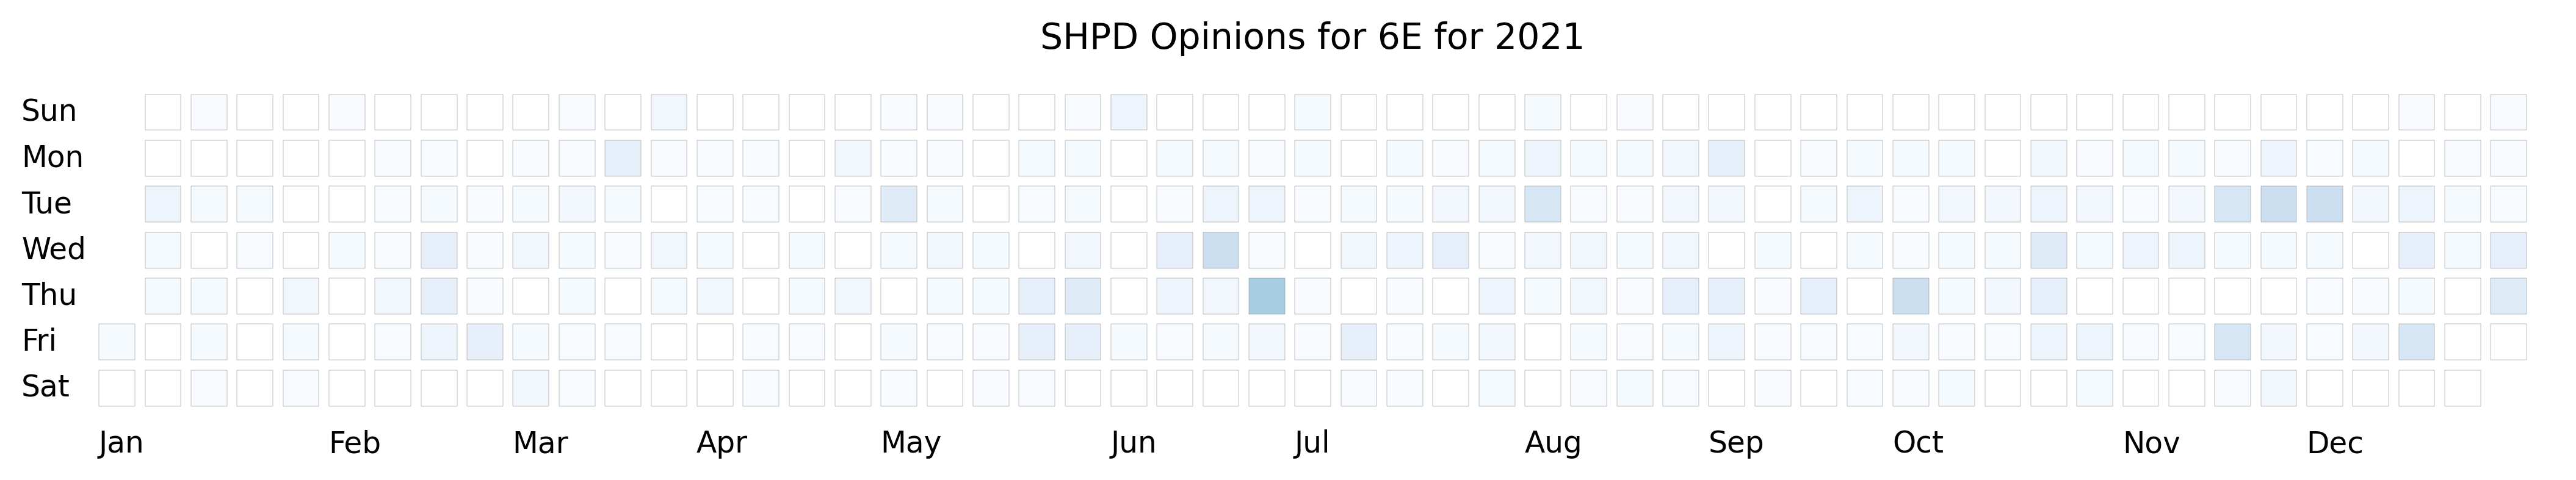

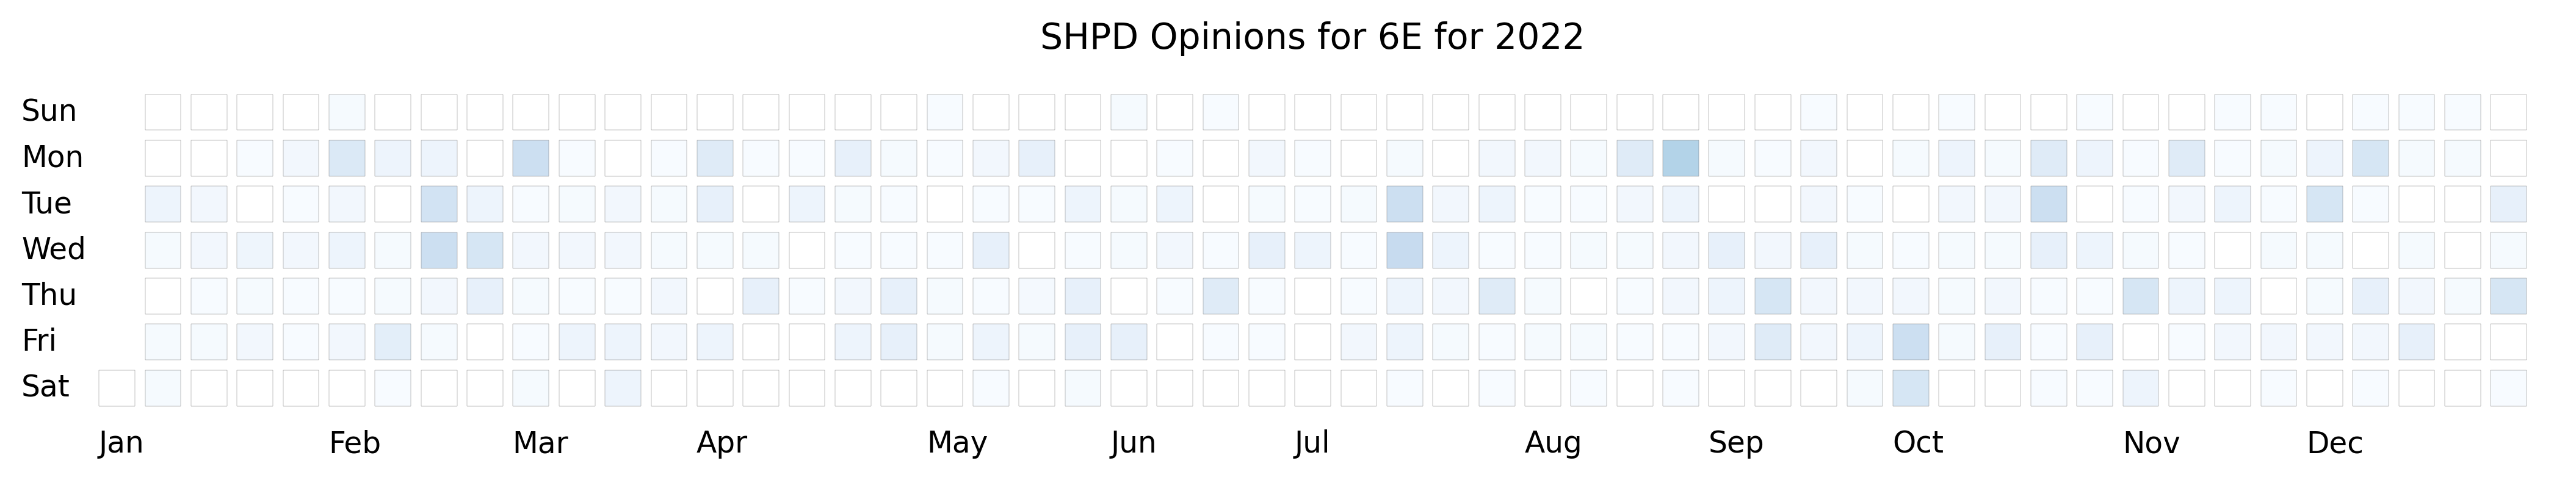

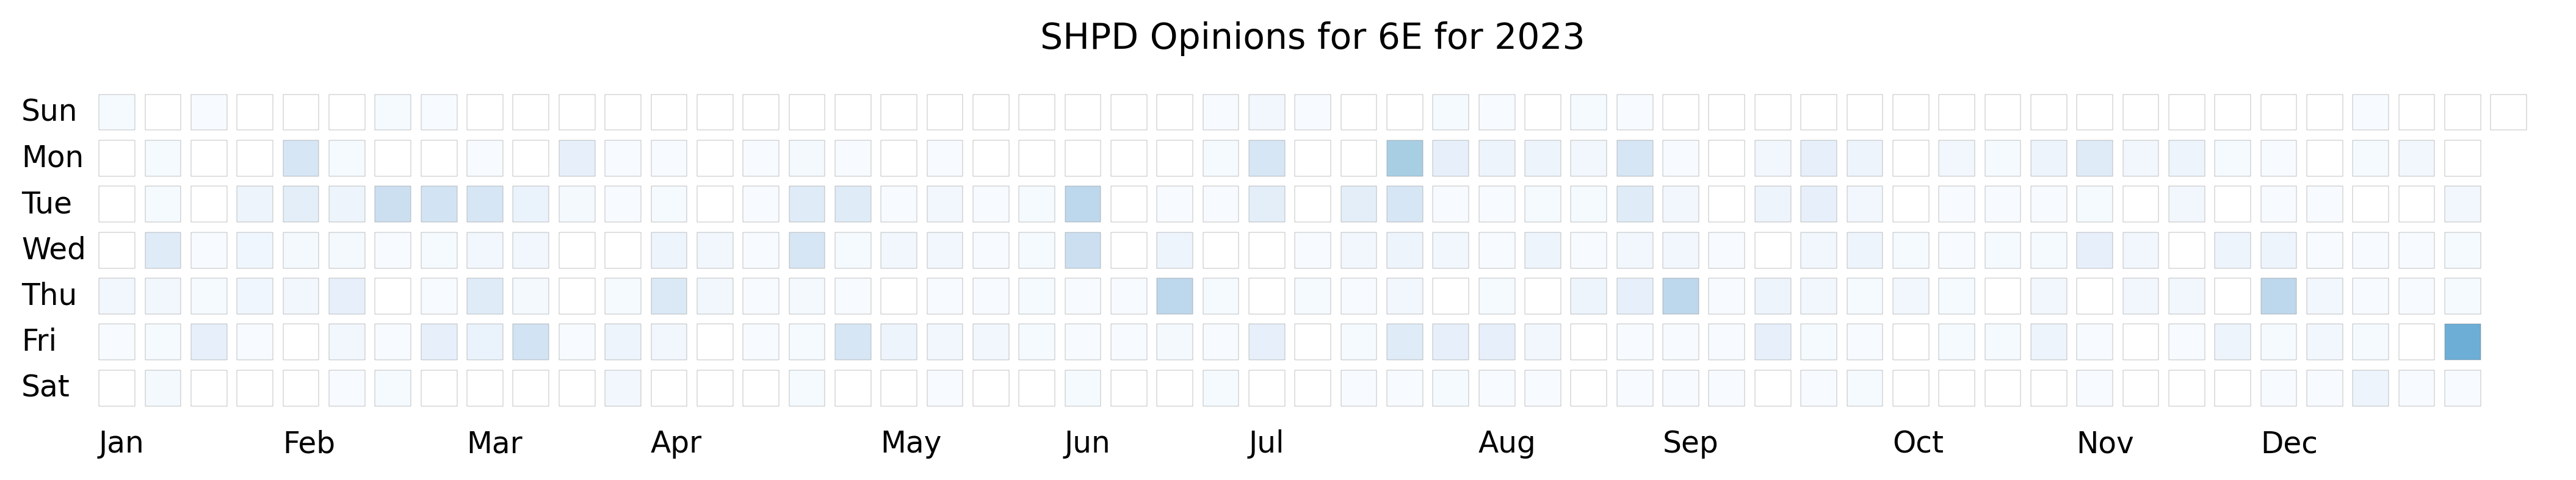

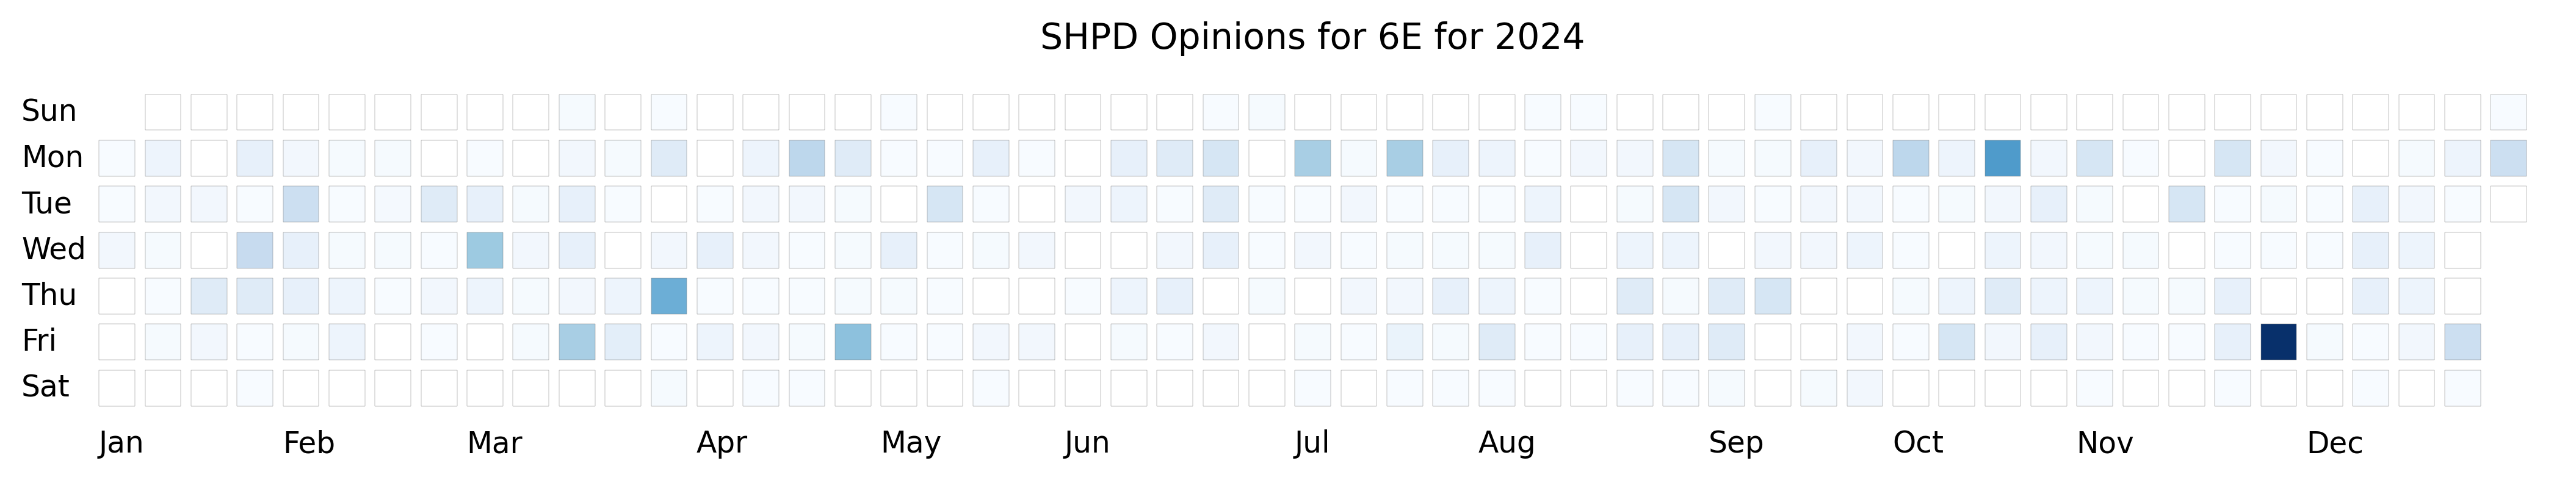

In [ ]:
import matplotlib.pyplot as plt
import dayplot as dp

# make df that is simple, dates and counts within each date.
dates_sixe = df[['Date Opinion 6E', 'Daily Count 6E']]

print(dates_sixe.head())

def calendar_plot_6e(df, code, year):
    dates_sixe = df[[f'Date Opinion {code}', f'Daily Count {code}']]
    fig, ax = plt.subplots(figsize=(15, 8), dpi=350)
    dp.calendar(
        dates=dates_sixe[f"Date Opinion {code}"],
        values=dates_sixe[f'Daily Count {code}'],
        start_date=f"{year}-01-01",
        end_date=f"{year}-12-31",
        cmap = "Blues",
        color_for_none="white",
        edgecolor="grey",  # black egdecolor
        edgewidth=.1,  # required to make the edges visible
        mutation_scale=0.8,  # smaller boxes
        ax=ax,
    )
    plt.title(f"SHPD Opinions for 6E for {year}")
    plt.show()

for year in valid_years:
    calendar_plot_6e(df, '6E', year)


In [ ]:
df_agg_2023 = df[df['Date Opinion 6E'].dt.year == 2023].groupby([df['Label'],
                     df['Date Opinion 6E'].dt.year])['Daily Count 6E'].sum()

print(df_agg_2023)
(
    ggplot(df, aes(x = 'Label')) + 
        geom_bar() +
        coord_flip()
)


Label              Date Opinion 6E
demolition         2023                70
nonresidential     2023               306
other              2023               597
public facilities  2023               394
public works       2023               285
residential        2023               578
site prep          2023               289
telecom            2023                63
water              2023               371
Name: Daily Count 6E, dtype: int64


PlotnineError: "Could not evaluate the 'x' mapping: 'reorder(Label)' (original error: reorder() missing 1 required positional argument: 'y')"

# Delays and Cost of Delays
We use the "RC data" from what Jon gave to us to estimate the different delay times between statutes. We would also like to see what we have to offer in terms of our label-based analysis. 

Finally, we should also compute the cost of delays using the construction index.
Based on the RLB cost construction indices for Q1 of each respective year + 1, we see that
- 2021: 3.97
- 2022: 5.06
- 2023: 5.50
- 2024: 5.37
  
We will then convert this to a daily rate, and then use that to calculate our 

In [13]:
# dr_2021 = (1+0.0397)**(1/365) - 1
# dr_2022 = (1+0.0506)**(1/365) - 1
# dr_2023 = (1+0.0550)**(1/365) - 1
# dr_2024 = (1+0.0537)**(1/365) - 1
dr_2021 = 0.0397/365
dr_2022 = 0.0506/365
dr_2023 = 0.0550/365
dr_2024 = 0.0537/365

# (ensure r has a default value just in case)
def interest_finder(year):
    rates = {2021: dr_2021, 2022: dr_2022, 2023: dr_2023, 2024: dr_2024}
    return rates.get(year, 0) # Returns 0 if year not in dictionary



def calculate_cost_delay(row):
    # defaults
    cost_6e = np.nan
    cost_106 = np.nan
    
    # Statutes contains '6E' (using 'in' because 'row' is a Series of one row)
    if 'HRS' in str(row['Statutes']):
        # row['Date Opinion 6E'] is a single timestamp, so we use .year directly
        year = row['Date Opinion 6E'].year
        r = interest_finder(year)
        cost_6e = ((1 + r)**row['delay_6e'] - 1) 
        
    # no elif here, separate condition
    if '106' in str(row['Statutes']):
        year = row['Date Opinion 106'].year
        r = interest_finder(year)
        cost_106 = ((1 + r)**row['delay_106'] - 1)

    # Return the new values as a Series to be added to the dataframe
    return pd.Series([cost_6e, cost_106])


# APPLY THE FUNCTION
df[['cost_delay_6e', 'cost_delay_106']] = df.apply(calculate_cost_delay, axis=1)

In [58]:
df['ultimate_time'] = df[['time_6e', 'time_106']].max(axis = 1)
df['ultimate_delay'] = df[['delay_6e', 'delay_106']].max(axis = 1)
# print(df.shape)
print("Average delay across all statutes:", np.ceil(np.mean(df['ultimate_delay'])))
print("Average time spent across all statutes:", np.ceil(np.mean(df['ultimate_time'])))


# calcuating the average, max and other descriptive stats of certain statutes 

df_10 = df[df['Statutes'].str.contains('6E-10')]
# print(df_10.describe())

df_42 = df[df['Statutes'].str.contains('6E-42')]
print(df_42['cost_delay_106'].describe())

Average delay across all statutes: 73.0
Average time spent across all statutes: 101.0
count    43.000000
mean      0.020458
std       0.030775
min       0.000000
25%       0.000000
50%       0.003705
75%       0.031051
max       0.125557
Name: cost_delay_106, dtype: float64


In [83]:
# how many of the projects are on-time with these deadlines?

perc_delayed_10_n = (df_10.loc[df['opinion_6e_binary'] == "no effect", "delay_6e"].gt(0)).mean()*100
perc_delayed_10_e = (df_10.loc[df['opinion_6e_binary'] == "effect", "delay_6e"].gt(0)).mean()*100
print("Percentage of HRS 6E-10 Delays for No Effect: ", perc_delayed_10_n)
print("Percentage of HRS 6E-10 Delays for Effect: ", perc_delayed_10_e)

perc_delayed_42_n = (df_42.loc[df['opinion_6e_binary'] == "no effect", "delay_6e"].gt(0)).mean()*100
perc_delayed_42_e = (df_42.loc[df['opinion_6e_binary'] == "effect", "delay_6e"].gt(0)).mean()*100
print("Percentage of HRS 6E-42 Delays for No Effect: ", perc_delayed_42_n)
print("Percentage of HRS 6E-42 Delays for Effect: ", perc_delayed_42_e)

perc_delayed_total = (df.loc[df['Statutes'].str.contains('6E-10') | df['Statutes'].str.contains('6E-42'), 'delay_6e']).gt(0).mean()*100
mean_delayed_total = (df.loc[df['Statutes'].str.contains('6E-10') | df['Statutes'].str.contains('6E-42'), 'delay_6e']).mean()
mean_time_total = (df.loc[df['Statutes'].str.contains('6E-10') | df['Statutes'].str.contains('6E-42'), 'time_6e']).mean()

print("Percentage of projects impacted by deadlines: ", np.ceil(perc_delayed_total))
print("Average delay for 6e-10 and 42: ", np.ceil(mean_delayed_total))
print("Average time spent for 6e-10 and 42: ", np.ceil(mean_time_total))


# checks for my tables
cost_reduction_10 = (df_10["cost_delay_6e"]).mean()*100
print("Average cost reduction for 6e-10: ", np.round(cost_reduction_10, 2))




Percentage of HRS 6E-10 Delays for No Effect:  85.9375
Percentage of HRS 6E-10 Delays for Effect:  50.0
Percentage of HRS 6E-42 Delays for No Effect:  50.86299892125135
Percentage of HRS 6E-42 Delays for Effect:  46.111111111111114
Percentage of projects impacted by deadlines:  52.0
Average delay for 6e-10 and 42:  60.0
Average time spent for 6e-10 and 42:  86.0
Average cost reduction for 6e-10:  1.79


# Issues and Outputs
Are there NHPA statutes that are put in opinion 6e??


In [ ]:
# df[df['Statutes'].str.contains('106')]['delay_6e'].count()

# are there gaps 

# Create a temporary dataframe of just the overlaps
overlaps = df[df['Statutes'].str.contains('106', na=False)].copy()

# Calculate the difference when 6e is bigger
overlaps['gap'] = overlaps['delay_6e'] - overlaps['delay_106']

# Look at projects where 6E took significantly longer, you can switch the < > and see
long_6e_gaps = overlaps[overlaps['gap'] < 0]
print(long_6e_gaps[['Statutes', 'delay_6e', 'delay_106', 'gap']])
print(long_6e_gaps.describe())

                                          Statutes  delay_6e  delay_106    gap
274                     HRS 6E-42,NHPA Section 106       0.0      399.0 -399.0
357                      HRS 6E-8,NHPA Section 106      65.0      320.0 -255.0
360                      HRS 6E-8,NHPA Section 106     122.0      318.0 -196.0
379                      HRS 6E-8,NHPA Section 106     530.0      644.0 -114.0
711                      HRS 6E-8,NHPA Section 106     368.0      428.0  -60.0
796   HRS 6E-42,HRS 6E-7,HRS 6E-8,NHPA Section 106     730.0      804.0  -74.0
967                       HRS 343,NHPA Section 106     798.0      966.0 -168.0
1040                              NHPA Section 106       0.0       42.0  -42.0
1411                    HRS 6E-42,NHPA Section 106     435.0      613.0 -178.0
1574                              NHPA Section 106       5.0        7.0   -2.0
1607                     HRS 6E-8,NHPA Section 106     242.0      281.0  -39.0
1773                     HRS 6E-8,NHPA Section 106  

In [82]:
import pandas as pd
from great_tables import GT, style, loc

# Map the search term to the specific delay column it should measure
statute_map = {
    '6E-42': 'delay_6e',
    '6E-8':  'delay_6e',
    '6E-3':  'delay_6e',
    '6E-10': 'delay_6e',
    '6E-7':  'delay_6e',
    '6E-43': 'delay_6e',
    '343':   'delay_6e',
    '106':   'delay_106'  # The outlier
}

stats_list = []

for code, col_name in statute_map.items():
    # Filter rows where 'Statutes' contains the code
    subset = df[df['Statutes'].str.contains(code, na=False, case=False)]
    
    if not subset.empty:
        # Pull stats for the SPECIFIC column assigned in our map
        desc = subset[col_name].describe()
        desc['Statute'] = code
        desc['Source_Col'] = col_name # Optional: keep track of which column was used
        stats_list.append(desc)

# Build the final DataFrame
summary_df = pd.concat(stats_list, axis=1).T.reset_index(drop=True)

# Clean up column order
cols = ['Statute', 'count', 'mean', 'std', 'min', 'max']
summary_df = summary_df[cols]
table = (
    GT(summary_df).tab_header(
        title="Project Delay Summary Statistics",
        subtitle="Includes proposed the 30 day and 90 day shot clocks"
    )
    .fmt_number(columns=["mean", "std", "min", "max"], decimals=1)
    .fmt_integer(columns=["count"])
    .tab_source_note(
        source_note="Note: Other statutes are included for comparison but are not in the proposed bill."
    )
    .tab_style(
        style=style.fill(color="lightblue"),
        locations=loc.body(rows=[0, 3]) 
    )
)

path = "../images"
table.save(f"{path}/project_summary.png", scale = 3)

GT(_tbl_data=  Statute   count        mean         std  min     max
0   6E-42  1881.0   58.223285  118.726178  0.0  1024.0
1    6E-8   549.0  123.100182  195.461607  0.0  1236.0
2    6E-3    71.0   23.915493   69.936859  0.0   426.0
3   6E-10    66.0  122.181818   180.06058  0.0  1271.0
4    6E-7    17.0  155.235294  221.641752  0.0   730.0
5   6E-43     6.0       370.5   427.47807  0.0  1110.0
6     343    33.0   88.818182  160.557905  0.0   798.0
7     106   113.0   171.40708  229.341357  0.0   966.0, _body=<great_tables._gt_data.Body object at 0x15fa872f0>, _boxhead=Boxhead([ColInfo(var='Statute', type=<ColInfoTypeEnum.default: 1>, column_label='Statute', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='min', type=<ColInfoTypeEnum.default: 1>, column_label='min', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x15fabfdd0>, _spanners=Spanners([]), _heading=Heading(title='Project Delay Summary Statistics', subtitle='Includes proposed the 30 day and 90 day shot clocks', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x15fabcb90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x15fabcb30>, _source_notes=['Note: Other statutes are included for comparison but are not in the proposed bill.'], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='Statute', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='Statute', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='count', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='count', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='mean', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='mean', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='std', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='std', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='min', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='min', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='max', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='max', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')])], _locale=<great_tables._gt_data.Locale object at 0x15fabf620>, _formats=[<great_tables._gt_data.FormatInfo object at 0x15fa636b0>, <great_tables._gt_data.FormatInfo object at 0x15fabc7a0>], _substitutions=[], _col_merge=[], _options=Options(t

In [86]:
# Map the statute to its corresponding COST column
cost_map = {
    '6E-42': 'cost_delay_6e',
    '6E-8':  'cost_delay_6e',
    '6E-3':  'cost_delay_6e',
    '6E-10': 'cost_delay_6e',
    '6E-7':  'cost_delay_6e',
    '6E-43': 'cost_delay_6e',
    '343':   'cost_delay_6e',
    '106':   'cost_delay_106'  # The outlier cost column
}

cost_stats = []

for code, col_name in cost_map.items():
    subset = df[df['Statutes'].str.contains(code, na=False, case=False)]
    
    if not subset.empty:
        # describe() gives us count, mean, std, min, 25%, 50%, 75%, max
        desc = subset[col_name].describe()
        desc['Statute'] = code
        cost_stats.append(desc)

# Create the summary DataFrame
cost_summary_df = pd.concat(cost_stats, axis=1).T.reset_index(drop=True)

# Reorder for the table
cols = ['Statute', 'count', 'mean', '50%', 'max', 'std']
cost_summary_df = cost_summary_df[cols]

table = (
    GT(cost_summary_df)
    .tab_header(
        title="Economic Impact of Regulatory Delays",
        subtitle="Includes proposed 30 and 90 day shot clocks in calculation"
    )
    # .cols_label(
    #     Statute="Statute",
    #     count="N",
    #     mean="Avg Cost",
    #     50%="Median Cost",
    #     max="Max Cost",
    #     std="Std Dev"
    # )
    # Format all numeric columns as currency (except 'count')
    .fmt_percent(
        columns=["mean", "50%", "max", "std"],
        decimals=3
    )
    .fmt_integer(columns=["count"])
    # Highlight the statutes of interest
    .tab_style(
        style=style.fill(color="lightblue"),
        locations=loc.body(rows=[0, 3]) 
    )
    .tab_source_note(
        source_note="Note: Other statutes are included for comparison but are not in the proposed bill."
        #Data Note: 106 values derived from 'cost_delay_106'; others from 'cost_delay_6e'
    )
)

path = "../images"
table.save(f"{path}/economic_impact_summary.png", scale = 3)

GT(_tbl_data=  Statute   count      mean       50%       max       std
0   6E-42  1881.0  0.008535  0.000693  0.162582  0.018089
1    6E-8   549.0  0.018375   0.00679  0.199411  0.030621
2    6E-3    71.0  0.003584       0.0  0.064675  0.010566
3   6E-10    66.0  0.017907  0.011986  0.205603  0.028431
4    6E-7    17.0  0.023529  0.004028  0.113371  0.034588
5   6E-43     6.0  0.057991  0.036839  0.177384  0.068758
6     343    33.0   0.01335  0.002505  0.124564   0.02478
7     106   171.0  0.016195  0.001472  0.152704   0.03006, _body=<great_tables._gt_data.Body object at 0x15fab6ab0>, _boxhead=Boxhead([ColInfo(var='Statute', type=<ColInfoTypeEnum.default: 1>, column_label='Statute', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='50%', type=<ColInfoTypeEnum.default: 1>, column_label='50%', column_align='right', column_width=None), ColInfo(var='max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x14fbc70e0>, _spanners=Spanners([]), _heading=Heading(title='Economic Impact of Regulatory Delays', subtitle='Includes proposed 30 and 90 day shot clocks in calculation', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x15fab5010>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x15fa63410>, _source_notes=['Note: Other statutes are included for comparison but are not in the proposed bill.'], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='Statute', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='Statute', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='count', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='count', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='mean', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='mean', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='50%', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='50%', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='max', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='max', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='std', rownum=0, colnum=None, styles=[CellStyleFill(color='lightblue')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 3], mask=None), grpname=None, colname='std', rownum=3, colnum=None, styles=[CellStyleFill(color='lightblue')])], _locale=<great_tables._gt_data.Locale object at 0x15fab74d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x15fab76b0>, <great_tables._gt_data.FormatInfo object at 0x15fab7c80>], _substitutions

In [ ]:
import pandas as pd
from great_tables import GT, loc, style

# Mapping Statutes to their respective delay and cost columns
statute_map = {
    '6E-42': ('delay_6e', 'cost_delay_6e'),
    '6E-8':  ('delay_6e', 'cost_delay_6e'),
    '6E-3':  ('delay_6e', 'cost_delay_6e'),
    '6E-10': ('delay_6e', 'cost_delay_6e'),
    '6E-7':  ('delay_6e', 'cost_delay_6e'),
    '6E-43': ('delay_6e', 'cost_delay_6e'),
    '343':   ('delay_6e', 'cost_delay_6e'),
    '106':   ('delay_106', 'cost_delay_106')
}

all_stats = []

for code, (delay_col, cost_col) in statute_map.items():
    # Filter for rows containing the statute
    subset = df[df['Statutes'].str.contains(code, na=False, case=False)]
    
    if not subset.empty:
        # Aggregate ONLY count, mean, std, and max (No median/min)
        res = subset.groupby('Label').agg({
            delay_col: ['count', 'mean', 'std', 'max'],
            cost_col: ['mean', 'max']
        })
        
        # Flatten the multi-index columns
        res.columns = ['Count', 'Delay_Avg', 'Delay_Std', 'Delay_Max', 'Cost_Avg', 'Cost_Max']
        res = res.reset_index()
        res['Statute'] = code
        all_stats.append(res)

final_df = pd.concat(all_stats, axis=0).reset_index(drop=True)

In [ ]:
table = (
    GT(final_df, groupname_col="Statute")
    .tab_header(
        title="Project Impact Summary",
        subtitle="Reviewing Time and Cost Delays by Project Label"
    )
    .cols_label(
        Label="Project Type",
        Count="N",
        Delay_Avg="Avg Days",
        Delay_Std="Std Dev",
        Delay_Max="Max Days",
        Cost_Avg="Avg Cost",
        Cost_Max="Max Cost"
    )
    # Formatting Numbers
    .fmt_number(columns=["Delay_Avg", "Delay_Std"], decimals=2)
    .fmt_integer(columns=["Count", "Delay_Max"])
    # Formatting Currency
    .fmt_percent(columns=["Cost_Avg", "Cost_Max"], decimals=3)
)

path = "../images"
table.save(f"{path}/project_impact_summary.pdf", dpi = 750)

GT(_tbl_data=                Label  Count    Delay_Avg   Delay_Std  Delay_Max  Cost_Avg  \
0          demolition     29    76.965517   98.825056      435.0  0.011301   
1      nonresidential    197    77.898477  142.470512     1024.0  0.011426   
2               other    421    69.441805  131.795800      961.0  0.010214   
3   public facilities    128   110.773438  139.457510      730.0  0.016291   
4        public works    141    34.021277   76.970446      515.0  0.004993   
5         residential    385    59.664935  122.627971      915.0  0.008784   
6           site prep    256    38.773438  101.340948      736.0  0.005561   
7             telecom     18   171.666667  182.310337      540.0  0.025489   
8               water    306    25.300654   69.160169      628.0  0.003667   
9          demolition      9   144.555556  164.086952      485.0  0.021576   
10     nonresidential     14   101.928571   74.814092      308.0  0.015189   
11              other    104   110.644231  189.659015     1164.0  0.016443   
12  public facilities    230   103.521739  170.294599     1203.0  0.015390   
13       public works    104   179.913462  254.045295     1236.0  0.027239   
14        residential     28   216.892857  294.037203     1022.0  0.033032   
15          site prep     21    63.952381   86.853599      272.0  0.008963   
16            telecom      2   123.500000   16.263456      135.0  0.017752   
17              water     37    85.486486   98.140665      415.0  0.012155   
18     nonresidential      3    32.000000   28.160256       53.0  0.004724   
19              other      9   100.666667  165.301996      426.0  0.015189   
20  public facilities      4    92.750000   82.947272      185.0  0.013841   
21        residential      5    13.800000   18.899735       35.0  0.002035   
22          site prep      2    59.000000   22.627417       75.0  0.008855   
23              water     48     2.875000    8.286428       37.0  0.000424   
24     nonresidential     11    99.909091   83.558907      258.0  0.014125   
25              other     25    98.320000  110.146009      511.0  0.014238   
26  public facilities      4   176.000000  157.454755      350.0  0.025868   
27       public works      4   227.500000  191.848030      515.0  0.032742   
28        residential     21    77.238095   78.672044      311.0  0.010975   
29          site prep      1  1271.000000         NaN     1271.0  0.205603   
30     nonresidential      1     0.000000         NaN        0.0  0.000000   
31              other      3   163.000000  163.024538      340.0  0.024272   
32  public facilities      9   224.555556  272.280697      730.0  0.034359   
33       public works      1     0.000000         NaN        0.0  0.000000   
34        residential      1   126.000000         NaN      126.0  0.017620   
35          site prep      1     0.000000         NaN        0.0  0.000000   
36              water      1     3.000000         NaN        3.0  0.000326   
37     nonresidential      0          NaN         NaN        NaN       NaN   
38              other      2   338.000000  347.896536      584.0  0.052408   
39  public facilities      3   515.666667  543.163266     1110.0  0.081044   
40          site prep      1     0.000000         NaN        0.0  0.000000   
41         demolition      2    92.500000   50.204581      128.0  0.013715   
42     nonresidential      1     0.000000         NaN        0.0  0.000000   
43              other     17   105.764706  205.664025      798.0  0.015939   
44  public facilities      3    91.666667  128.578122      240.0  0.013403   
45       public works      1   130.000000         NaN      130.0  0.019309   
46        residential      7    26.857143   35.853538       92.0  0.003994   
47            telecom      1    23.000000         NaN       23.0  0.003389   
48              water      1   332.000000         NaN      332.0  0.051296   
49         demolition      2   311.500000  426.385389      613.0  0.031960   
50     no